In [ ]:
# -*- coding: utf-8 -*-
"""
Created on Sat Apr 25 14:41:11 2026

@author: Cacob
"""

# Este trabalho tem como objetivo investigar se melhores práticas de gestão empresarial
# estão associadas a melhores indicadores econômicos em nível nacional.
#
# Para isso, são utilizadas duas bases de dados: uma base de eficiência e gestão das empresas,
# inspirada na metodologia de Bloom e Van Reenen, e uma base de indicadores macroeconômicos
# do World Bank Data 2025.
#
# A análise busca verificar a existência de correlações entre o índice médio de gestão das firmas
# e variáveis econômicas agregadas, como PIB per capita, taxa de desemprego e inflação.


# ===============================================
# PASSO 1: Importanto as bibliotecas necessárias
# ===============================================


from Regressoes import preparar_management_pais_ano, rodar_modelo_management_macro # meu pacote de regressão linear
import pandas as pd # pandas para manipulação de dados
import matplotlib.pyplot as plt # matplot para gráficos
import numpy as np # np para cálculos numéricos
from pathlib import Path # Path para trabalhar com caminhos e diretórios
import scipy.stats as stats # Stats para estatística avançada
from Histogramas import ComparadorHistogramas # meu pacote para histogramas

plt.style.use("ggplot")
plt.rcParams["font.family"] = "monospace"

### Célula 1: Bibliotecas, pacotes auxiliares e objetivo do trabalho




In [ ]:
# ========================================================
# PASSO 2: Tornando o diretório do trabalho relativo
# ========================================================

# Código para tornar o diretório da base de dados relativo (Executar em qualquer PC)
try:
    diretorio_base = Path(__file__).resolve().parent # Funciona quando o código está em um arquivo .py
except NameError:
    diretorio_base = Path.cwd() # Funciona quando o código está em um notebook Jupyter

# Caminho relativo até a planilha Empresas.xlsx
caminho_empresas = diretorio_base / "dados" / "Empresas.xlsx"
caminho_macro = diretorio_base / "dados" / "world_bank_data_2025.csv"

# Importa a planilha
empresas = pd.read_excel(caminho_empresas) # dados com as avaliações das empresas de acordo com cada critério numa escala de 1 a 5
empresas.info(memory_usage='deep') # examinando o tipo de arquivo de cada coluna

paises_dados = pd.read_csv(caminho_macro) # dados com as informações sobre dados economicos dos principais países nos ultimos anos
paises_dados.info(memory_usage = " deep ")


# tratando a base de dados macroeconomica

paises_dados["year"] = paises_dados["year"].astype("int16")

colunas_float32 = [
    "Inflation (CPI %)",
    "GDP (Current USD)",
    "GDP per Capita (Current USD)",
    "Unemployment Rate (%)",
    "Interest Rate (Real, %)",
    "Inflation (GDP Deflator, %)",
    "GDP Growth (% Annual)",
    "Current Account Balance (% GDP)",
    "Government Expense (% of GDP)",
    "Government Revenue (% of GDP)",
    "Tax Revenue (% of GDP)",
    "Gross National Income (USD)",
    "Public Debt (% of GDP)"
]

for coluna in colunas_float32:
    paises_dados[coluna] = paises_dados[coluna].astype("float32") # otimizando o tipo de arquivo das colunas via loop for, sem perder informação

paises_dados = paises_dados.drop(columns=["Inflation (GDP Deflator, %)"]) # dropando coluna que não é de interesse para economizar memória e evitar confusão entre diferentes colunas "inflation"

paises_dados_limpo = paises_dados.copy()

paises_dados_limpo.columns = (
    paises_dados_limpo.columns
    .str.replace(r"\s*\([^)]*\)", "", regex=True) # expressão regular para remover e apagar itens dos parentesis dentro das colunas
    .str.strip()
)


paises_dados_limpo.rename(columns = {"country_name": "country"}, inplace = True)

paises_dados_limpo.info(memory_usage = "deep")

condicoes = [
    (paises_dados_limpo["GDP per Capita"] > 1) & (paises_dados_limpo["GDP per Capita"] <= 8000),
    (paises_dados_limpo["GDP per Capita"] > 8000) & (paises_dados_limpo["GDP per Capita"] <= 16000),
    (paises_dados_limpo["GDP per Capita"] > 16000) & (paises_dados_limpo["GDP per Capita"] <= 30000),
    (paises_dados_limpo["GDP per Capita"] > 30000) # categorizando o nível de renda dos países de acordo com a renda per capita
]

categorias = ["baixo", "medio", "alto", "muito alto"]

paises_dados_limpo["nível_pib_per_capita"] = np.select(
    condicoes,
    categorias,
    default="sem_classificação"  # se nenhuma das categorias for aplicada, use "sem classificação" como valor, útil para dados faltantes.
)


### Célula 2: Carregamento das bases e definição dos caminhos




In [ ]:
# ====================================
# PASSO 3 tratando a planilha empresas
# ====================================

# Planilha de empresas sem dados faltantes na coluna "talent6"
# .copy() evita problemas posteriores ao criar novas colunas
empresas = empresas.dropna(subset=["talent6"]).copy()

empresas.rename(columns = {"wave": "year"}, inplace = True)

colunas_criterios = {
    "operations": ["lean1", "lean2"],
    "monitor": ["perf1", "perf2", "perf3", "perf4", "perf5"],
    "people": ["talent1", "talent2", "talent3", "talent4", "talent5", "talent6"],
    "target": ["perf6", "perf7", "perf8", "perf9", "perf10"]
}

def médias_colunas(dados, critério):
    return dados[critério].mean(axis=1).round(2)


for nome_criterio, colunas in colunas_criterios.items():
    empresas[nome_criterio] = médias_colunas(empresas, colunas) # loop for para tirar as médias das colunas agrupadas em "colunas_criterios"


empresas["management"] = (empresas[["operations", "monitor", "people", "target"]].mean(axis=1).round(2)) # axis = 1 faz uma média linha a linha

###  Célula 3: Tratamento da base de empresas e construção do índice de gestão

**Resultado gerado:**  

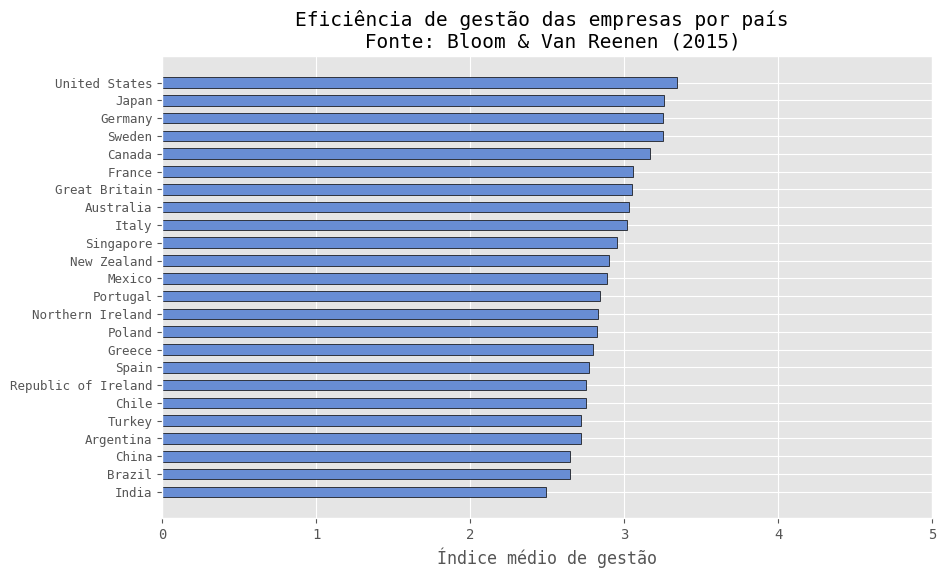

Aqui podemos ver brevemente que países mais desenvolvidos, tendem a possuir instituições mais eficientes



In [ ]:
# =======================================================================================
# PASSO 4: Agrupando colunas semelhantes em uma única coluna que será a média das demais
# =======================================================================================

colunas_ranking = [
    "country","year","operations", "monitor",
    "people","target","management"
]

médias_por_critério = empresas.loc[:, colunas_ranking].copy()

ranking_países = (médias_por_critério.groupby("country", as_index=True).mean(numeric_only=True).round(2))

ranking_ordenado = ranking_países.sort_values(by="management",ascending=True)

# ===================================================================================
# PASSO 5 Gráfico de barras dos países com as melhores empresas em ordem decrescente
# ===================================================================================

plt.figure(figsize=(14, 6))

plt.barh(                      #plot gráfico de barras horizontal
    ranking_ordenado.index,
    ranking_ordenado["management"],
    color="#688dd4",
    height=0.6,
    edgecolor="black"
)

plt.tick_params(axis="y", labelsize=9)
plt.tick_params(axis="x", labelsize=10)

plt.title("Eficiência de gestão das empresas por país \n Fonte: Bloom & Van Reenen (2015)", fontsize=14, loc="center")
plt.xlabel("Índice médio de gestão", fontsize=12)

plt.subplots_adjust(left=0.35)
plt.xlim(0, 5)

plt.show()

### Célula 4: Ranking do índice médio de gestão por país

**Resultado gerado:**  
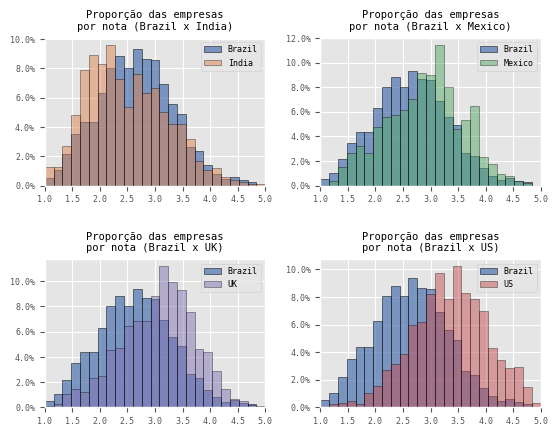




In [ ]:
# =====================================================================
# PASSO 6 - Criando Histogramas para comparar a distribuição das notas
# Aqui irei importar  a classe "Histrogramas" que possui as funções definidas nela
# =====================================================================


separações = np.linspace(1, 5, 26)  # criando intervalos do histrograma de 1 a 5 e repartições que são de 25 pedaços iguais ( n + 1)


def filtrar_empresas_por_pais(tabela, país):
    return tabela.loc[tabela["country"].eq(país), "management"].dropna()


paises_para_comparar = {
    "Brazil": "Brazil",
    "India": "India",
    "Mexico": "Mexico",
    "Great Britain": "Great Britain",
    "United States": "United States"
}

empresas_por_pais = {
    nome_objeto: filtrar_empresas_por_pais(médias_por_critério, nome_pais)
    for nome_objeto, nome_pais in paises_para_comparar.items()
}


brasil_empresas = empresas_por_pais["Brazil"] # filtrando base de dados para cada país
india_empresas = empresas_por_pais["India"]
Mexico_empresas = empresas_por_pais["Mexico"]
Reino_Unido_empresas = empresas_por_pais["Great Britain"]
Estados_Unidos_empresas = empresas_por_pais["United States"]

        
dados_paises = {
    "Brazil": brasil_empresas,
    "India": india_empresas,
    "Mexico": Mexico_empresas,
    "UK": Reino_Unido_empresas,
    "US": Estados_Unidos_empresas
}

cores = {
    "Brazil": "#4C72B0",
    "India": "#DD8452",
    "Mexico": "#55A868",
    "UK": "#8172B3",
    "US": "#C44E52"
}

comparador = ComparadorHistogramas(
    dados_paises=dados_paises,
    cores=cores,
    separacoes=separações,
    pais_base="Brazil"
)

comparacoes = [
    "India",
    "Mexico",
    "UK",
    "US"
]

comparador.plotar_grade(comparacoes)


### Célula 5: Distribuição proporcional do índice de gestão

**Resultado gerado:**  
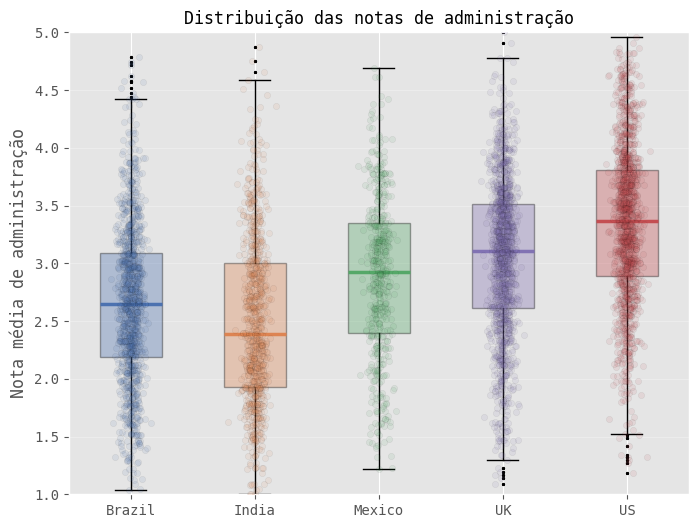

In [ ]:
# ============================================================
# PASSO 7: Visualizando a dispersão dos dados por BoxPlot
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))


labels = list(dados_paises.keys()) # pegando as chaves do dicionario países para definir as legendas
dados = list(dados_paises.values()) # pegando os valores do dicionario países
posicoes = np.arange(1, len(labels) + 1) # posicionando cada boxplot baseado na ordem do dicionario países

boxplot = ax.boxplot(dados, labels=labels, patch_artist=True, widths=0.5,
    flierprops=dict(
        marker='*',
        markersize=2,
        markerfacecolor='black',
        markeredgecolor='black'
    )
)

for caixa, mediana, pais in zip(boxplot["boxes"], boxplot["medians"], labels):
    cor = cores[pais]

    caixa.set_facecolor(cor)
    caixa.set_edgecolor("black")
    caixa.set_alpha(0.35)

    mediana.set_color(cor)
    mediana.set_alpha(1)
    mediana.set_linewidth(2.5)

for posicao, pais in zip(posicoes, labels):
    valores = dados_paises[pais]

    jitter = np.random.normal(loc=posicao, scale=0.05, size=len(valores))

    ax.scatter(jitter, valores, color=cores[pais],
        alpha=0.10, 
        s=20, 
        edgecolor="black", 
        linewidth=0.3, 
        zorder=3)

ax.set_title("Distribuição das notas de administração", fontsize=12)
ax.set_ylabel("Nota média de administração")
ax.set_ylim(1, 5)

ax.grid(axis="y", alpha=0.3)

plt.show()

### Célula 6: Dispersão do índice de gestão por país





In [ ]:
# ===========================================
# Passo 8 Medindo a confiabilidade da Amostra
# ===========================================

paises = [
    "Brazil",
    "United States",
    "Great Britain",
    "India",
    "Mexico"
]

dados_confianca = médias_por_critério[
    médias_por_critério["country"].isin(paises)
][["country", "management"]].dropna()

tabela_confianca = (
    dados_confianca
    .groupby("country")["management"]
    .agg(
        media="mean",
        desvio_padrao="std",
        numero_firmas="count"
    )
    .reset_index()
)

tabela_confianca["erro_padrao"] = (tabela_confianca["desvio_padrao"] / np.sqrt(tabela_confianca["numero_firmas"]))

tabela_confianca["t_critico"] = stats.t.ppf(0.975,df=tabela_confianca["numero_firmas"] - 1)

tabela_confianca["margem_erro_95"] = (tabela_confianca["t_critico"] * tabela_confianca["erro_padrao"])

tabela_confianca["limite_inferior_95"] = (tabela_confianca["media"] - tabela_confianca["margem_erro_95"])

tabela_confianca["limite_superior_95"] = (tabela_confianca["media"] + tabela_confianca["margem_erro_95"])

tabela_confianca = tabela_confianca.round(3)

tabela_confianca

###  Célula 7: Intervalos de confiança para o índice médio de gestão





In [ ]:
# ============================================================
# passo 9 Vendo se há diferenças de eficiencia de gestão dada
# diferentes niveis de competitividade
# e diferentes tipos de "onwers" da empresa
# ============================================================

def tabela_condicional(dados, grupo, variavel):
    tabela = (
        dados
        .groupby(["country", grupo])[variavel]
        .agg(
            media="mean",
            desvio_padrao="std",
            numero_firmas="count"
        )
        .reset_index()
    )

    tabela["erro_padrao"] = (tabela["desvio_padrao"] / np.sqrt(tabela["numero_firmas"]))

    tabela["t_critico"] = stats.t.ppf(0.975,df=tabela["numero_firmas"] - 1)

    tabela["margem_erro_95"] = (tabela["t_critico"] * tabela["erro_padrao"])

    tabela["limite_inferior_95"] = (tabela["media"] - tabela["margem_erro_95"])

    tabela["limite_superior_95"] = (tabela["media"] + tabela["margem_erro_95"])

    return tabela.round(3)


dados_ownership = empresas.loc[
    empresas["country"].isin(paises),
    ["country", "ownership", "management"]
].dropna()


tabela_management_ownership = tabela_condicional(
    dados_ownership,
    grupo="ownership",
    variavel="management"
)


dados_competition = empresas.loc[
    empresas["country"].isin(paises),
    ["country", "competition", "management"]
].dropna()


tabela_management_competition = tabela_condicional(
    dados_competition,
    grupo="competition",
    variavel="management"
)

# ===============================================================
# preparando base de dados que será usada para a regressão linear
# ===============================================================


management_pais_ano = (
    médias_por_critério
    .groupby(["country", "year"], as_index=False)
    .agg(
        management_medio=("management", "mean"),
        operations_medio=("operations", "mean"),
        monitor_medio=("monitor", "mean"),
        people_medio=("people", "mean"),
        target_medio=("target", "mean"),
        desvio_management=("management", "std"),
        numero_firmas=("management", "count")
    )
)

macro_modelo = paises_dados_limpo.copy()

# Garantindo que os nomes das colunas não tenham espaços escondidos
macro_modelo.columns = macro_modelo.columns.str.strip()

# Padronizando year
macro_modelo["year"] = pd.to_numeric(macro_modelo["year"]).astype("Int16")

# Padronizando country
macro_modelo["country"] = (
    macro_modelo["country"]
    .astype(str)
    .str.strip()
)

# Ajustando nomes diferentes entre as bases
mapa_paises = {
    "United Kingdom": "Great Britain",
    "UK": "Great Britain",
    "United States of America": "United States",
    "USA": "United States"
}

macro_modelo["country"] = macro_modelo["country"].replace(mapa_paises)

# Garantindo que GDP per Capita está numérico
macro_modelo["GDP per Capita"] = pd.to_numeric(macro_modelo["GDP per Capita"])

# Mantendo só as colunas necessárias para a regressão
macro_modelo = macro_modelo[["country", "year", "GDP per Capita", "nível_pib_per_capita"]].copy()

print("Base macro para modelo:")
print(macro_modelo.head())


### Célula 8: Intervalos de confiança para o índice médio de gestão


In [ ]:
# =========================================================
# PASSO 10: Juntando as bases para cálculo de Regressão
# =========================================================

merge_diagnostico = management_pais_ano.merge(
    macro_modelo,
    on=["country", "year"],
    how="outer",
    indicator=True
)

# ======================================
# PASSO 11 - Base final para regressão
# ======================================

base_modelo = management_pais_ano.merge(
    macro_modelo,
    on=["country", "year"],
    how="inner",
    validate="one_to_one"
)

# Removendo linhas sem GDP per capita ou sem management
base_modelo = base_modelo.dropna(
    subset=["GDP per Capita", "management_medio"]
).copy()

# Criando log do PIB per capita
base_modelo["log_gdp_per_capita"] = np.log(base_modelo["GDP per Capita"])

print("Base final do modelo:")
print(base_modelo.head())

print("\nDimensão da base final:")
print(base_modelo.shape)

print("\nPaíses presentes na base final:")
print(base_modelo["country"].unique())

# ============================================================
# PASSO 12 - Correlação simples entre ppc e management
# ============================================================

correlacao = base_modelo["management_medio"].corr(
    base_modelo["log_gdp_per_capita"]
)

print("Correlação entre management médio e log do PIB per capita:")
print(correlacao)


### Resultado e interpretação — Célula 9: Junção das bases de gestão e macroeconomia

**Resultado gerado:**  
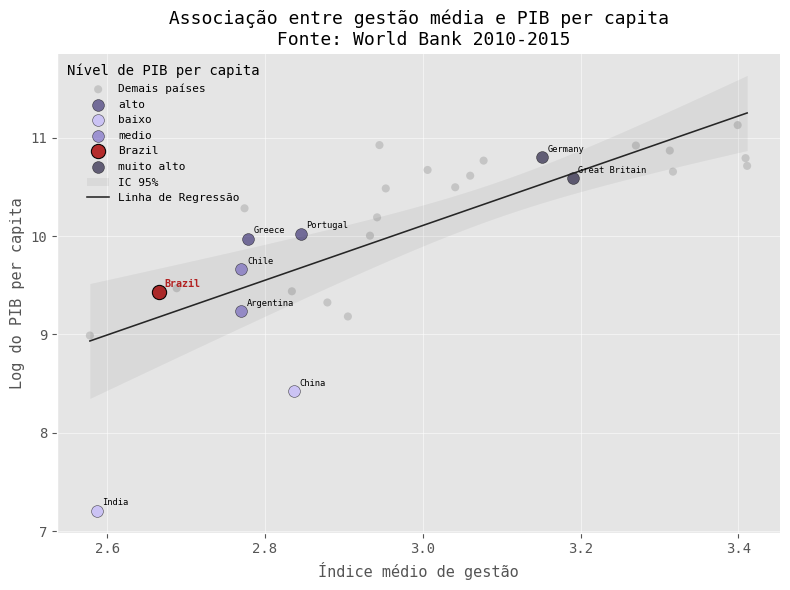

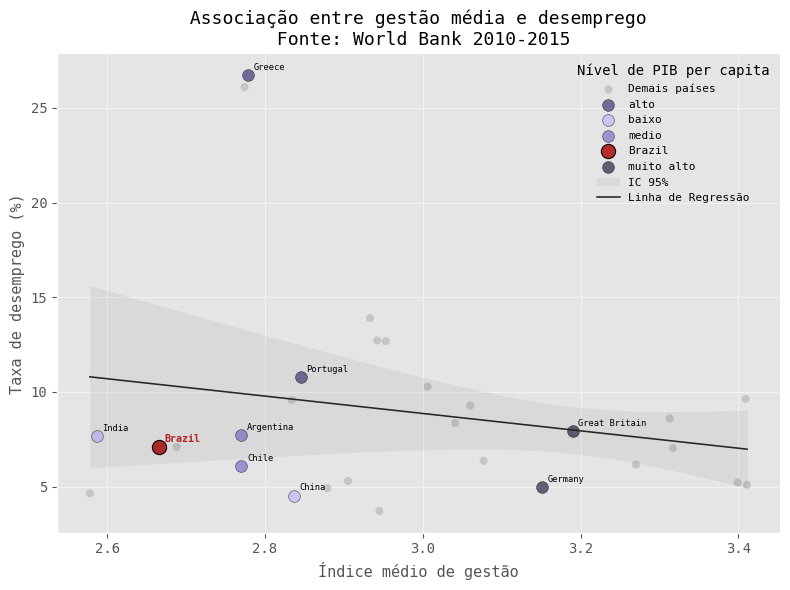

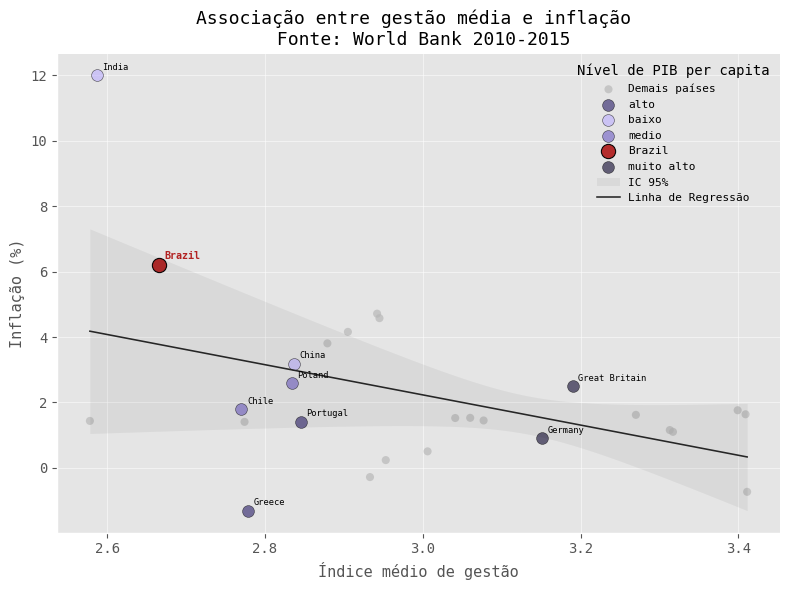


**Conclusão:**

É possível denotar que existe uma forte **correlação** entre empresas e instituições melhores, com melhores indicativos econômicos. No entanto, é válido ressaltar que esse trabalho
não visa estabelecer quaisquer relações de causalidade, logo, não é possível afirmar com certeza, se melhores empresas causam melhor desenvolvimento em cada país



In [ ]:
# ============================================================
# PASSO 13 - Regressão linear simples
# ============================================================

# ============================================================
# 1. Agregar management para país-ano
# ============================================================

import importlib
import Regressoes
importlib.reload(Regressoes) # sem isso eu não estava conseguindo importar meu pacote por algum motivo.

management_pais_ano = preparar_management_pais_ano(médias_por_critério)

# ============================================================
# MODELO 1 - PIB per capita e management
# ============================================================

base_pib, modelo_pib = rodar_modelo_management_macro(
    dados_management=management_pais_ano,
    dados_macro=paises_dados_limpo,
    coluna_macro="GDP per Capita",
    nome_modelo="log_gdp_per_capita",
    titulo_grafico=" Associação entre gestão média e PIB per capita \n Fonte: World Bank 2010-2015",
    rotulo_y="Log do PIB per capita",
    transformar_log=True
)


# ============================================================
# MODELO 2 - Desemprego e management
# ============================================================

base_desemprego, modelo_desemprego = rodar_modelo_management_macro(
    dados_management=management_pais_ano,
    dados_macro=paises_dados_limpo,
    coluna_macro="Unemployment Rate",
    nome_modelo="taxa_desemprego",
    titulo_grafico=" Associação entre gestão média e desemprego \n Fonte: World Bank 2010-2015",
    rotulo_y="Taxa de desemprego (%)",
    transformar_log=False
)


# ============================================================
# MODELO 3 - Inflação e management
# ============================================================


base_inflacao, modelo_inflacao = rodar_modelo_management_macro(
    dados_management=management_pais_ano,
    dados_macro=paises_dados_limpo,
    coluna_macro="Inflation",
    nome_modelo="inflacao",
    titulo_grafico="Associação entre gestão média e inflação \n Fonte: World Bank 2010-2015",
    rotulo_y="Inflação (%)",
    transformar_log=False
)